Accuracy: 84.47%
              precision    recall  f1-score   support

        bike       0.92      0.81      0.86       372
         bus       0.75      0.70      0.72       460
         car       0.80      0.74      0.77       351
        walk       0.87      0.95      0.91      1083

    accuracy                           0.84      2266
   macro avg       0.84      0.80      0.82      2266
weighted avg       0.84      0.84      0.84      2266



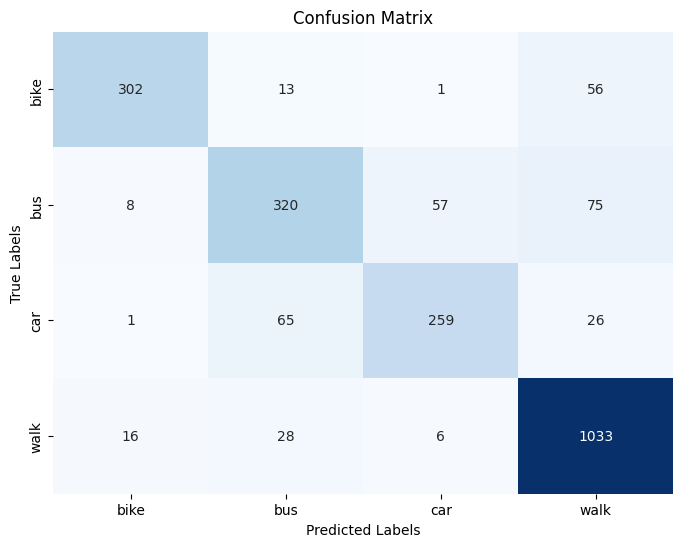

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier


df = pd.read_csv("segment_features.csv")


X = df.drop(columns=["mode", "file_name", "user_id", "segment_id"])
y = df["mode"]

# Om det finns textkolumner förutom mode, ta bort dem automatiskt
#X = X.select_dtypes(include=["number"])


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

classifier.fit(X_train, y_train)


y_pred = classifier.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


print(classification_report(y_test, y_pred))


labels = sorted(y.unique())
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="g",
    cmap="Blues",
    cbar=False,
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


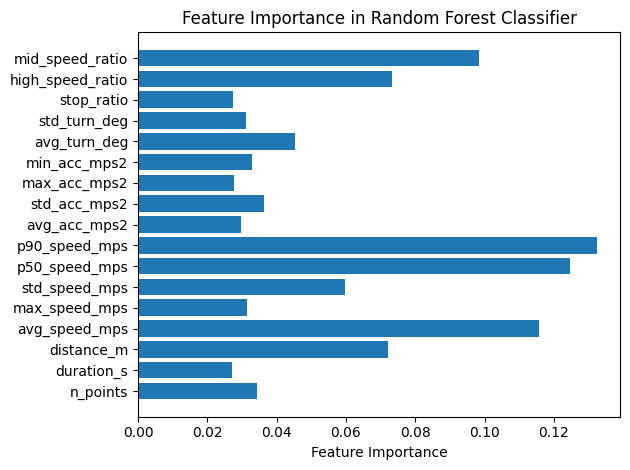

In [63]:

# Sortera från störst till minst
feature_importances = classifier.feature_importances_



plt.barh(X.columns, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.tight_layout()



plt.show()

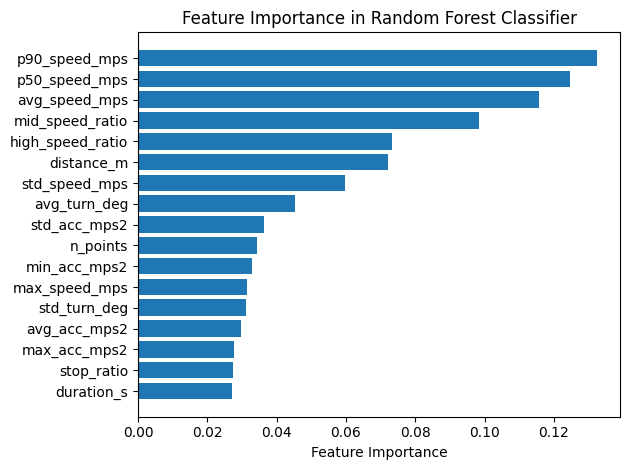

In [64]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': classifier.feature_importances_
})

# Sortera från störst till minst
importance_df = importance_df.sort_values(by='Importance', ascending=True)



plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.tight_layout()



plt.show()

In [65]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print(classification_report(y_test, y_pred_knn))


              precision    recall  f1-score   support

        bike       0.84      0.80      0.82       372
         bus       0.68      0.64      0.66       460
         car       0.74      0.64      0.69       351
        walk       0.87      0.94      0.90      1083

    accuracy                           0.81      2266
   macro avg       0.78      0.76      0.77      2266
weighted avg       0.81      0.81      0.81      2266



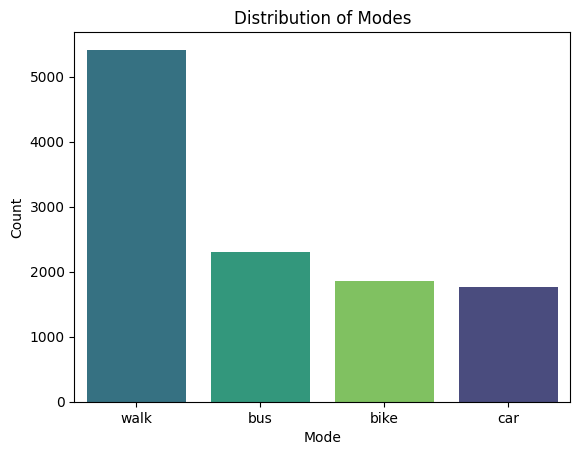

In [66]:
sns.countplot(data=df,x="mode", hue="mode", palette="viridis", order=df["mode"].value_counts().index)

plt.title("Distribution of Modes")
plt.xlabel("Mode")
plt.ylabel("Count")
plt.show()

In [67]:

# Skapar en SVM-modell med RBF-kernel
# RBF fungerar bra för komplex och icke-linjär data
svm = SVC(kernel="rbf", C=1, gamma="scale")

# Tränar modellen på träningsdatan
svm.fit(X_train_scaled, y_train)

# Modellen gör prediktioner på testdatan
y_pred_svm = svm.predict(X_test_scaled)

# Räknar ut modellens accuracy
accuracy = accuracy_score(y_test, y_pred_svm)

# Skriver ut accuracy i procent
print(f"SVM Accuracy: {accuracy * 100:.2f}%")

# Skriver ut precision, recall och F1-score för varje klass
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 81.51%
              precision    recall  f1-score   support

        bike       0.87      0.79      0.83       372
         bus       0.71      0.63      0.67       460
         car       0.76      0.63      0.69       351
        walk       0.85      0.96      0.90      1083

    accuracy                           0.82      2266
   macro avg       0.80      0.75      0.77      2266
weighted avg       0.81      0.82      0.81      2266



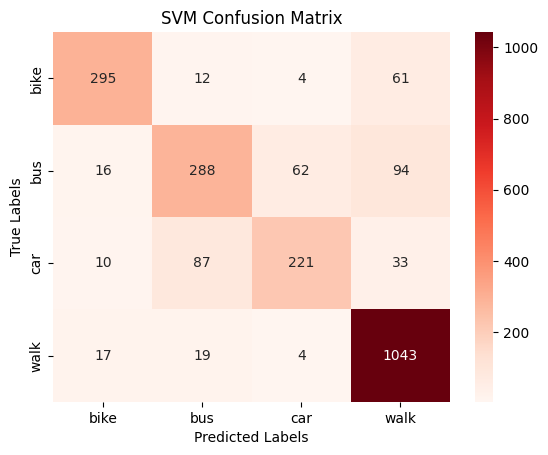

In [70]:
conf_matrix = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=labels
)

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="g",
    cmap="Reds",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()